# Tahap : Model & Interpret (OSEMN Framework)
Deskripsi : Analisis Eksploratif (Trend & Distribusi), Analisis Korelasi, Pemodelan Clustering (K-Means), dan Feature Importance (Random Forest)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor

# Pengaturan estetika visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## Load Dataset

In [2]:
print("[INFO] Memuat dataset hasil preprocessing...")
df_monthly = pd.read_csv('../data/preprocessed/stunting_cleaned_monthly.csv')
df_yearly = pd.read_csv('../data/preprocessed/stunting_agg_puskesmas_yearly.csv')

# Mengurutkan bulan secara kronologis untuk trend analysis
bulan_order = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 
               'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']
df_monthly['bulan'] = pd.Categorical(df_monthly['bulan'], categories=bulan_order, ordered=True)

[INFO] Memuat dataset hasil preprocessing...


## Exploratory Data Analysis (EDA)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22980\520719066.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend_data = df_monthly.groupby('bulan')['total_stunting'].sum().reset_index()


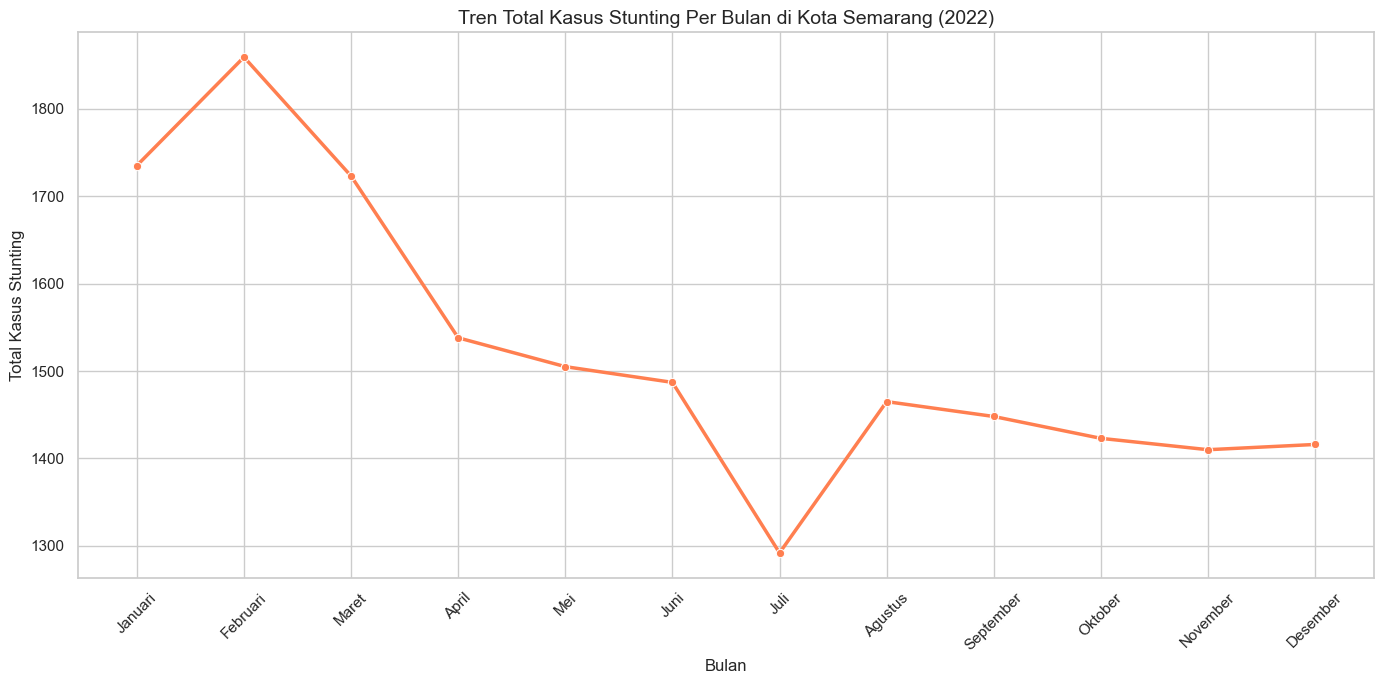

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22980\520719066.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kecamatan_stunting, x='total_stunting', y='kecamatan', palette='viridis')


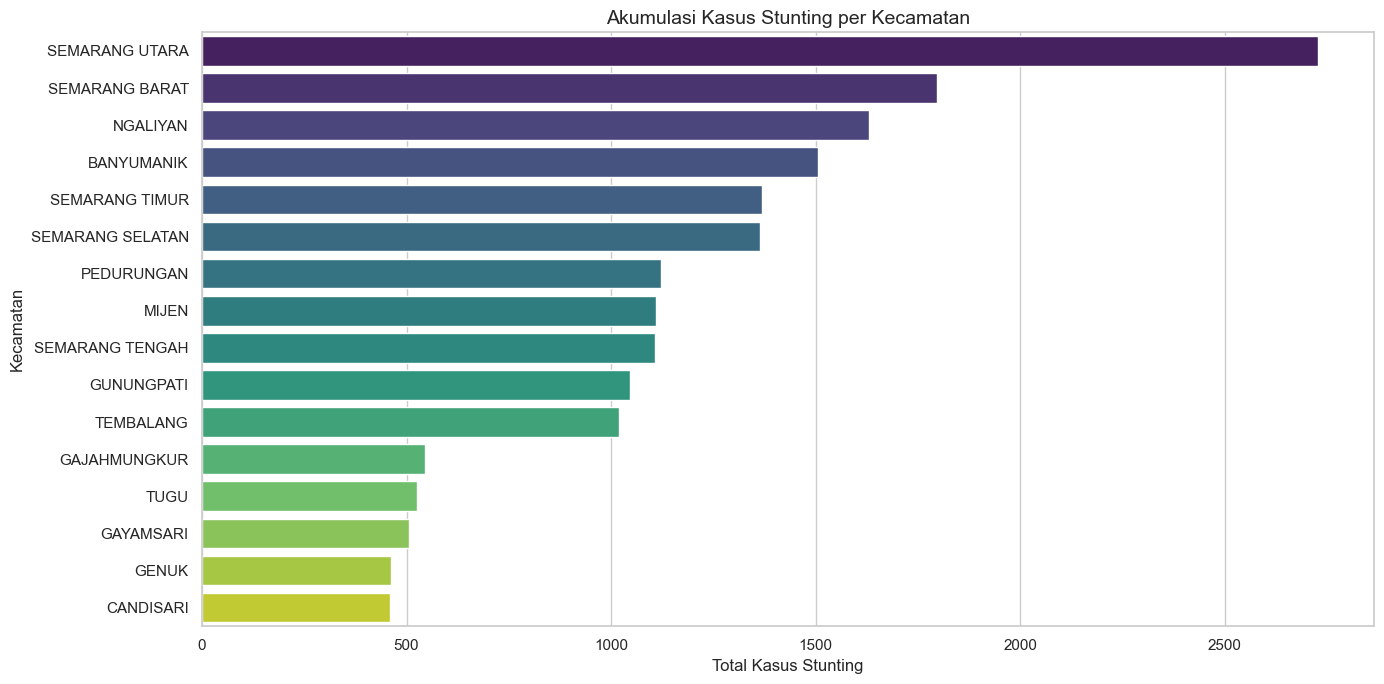

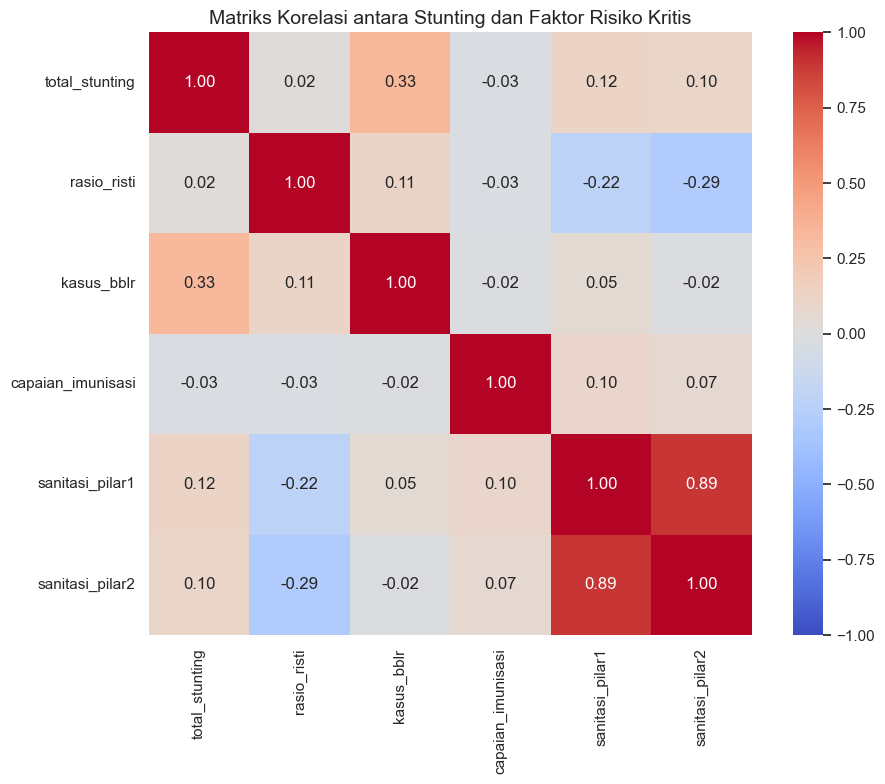

In [ ]:
# Q1: Analisis Tren Kasus Stunting Bulanan
plt.figure(figsize=(14, 7))
trend_data = df_monthly.groupby('bulan')['total_stunting'].sum().reset_index()
sns.lineplot(data=trend_data, x='bulan', y='total_stunting', marker='o', linewidth=2.5, color='coral')
plt.title('Tren Total Kasus Stunting Per Bulan di Kota Semarang (2022)')
plt.xlabel('Bulan')
plt.ylabel('Total Kasus Stunting')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../docs/trend_stunting_bulanan.png', dpi=300)
plt.show()

# Q2: Distribusi Kasus Stunting Berdasarkan Kecamatan
plt.figure(figsize=(14, 7))
kecamatan_stunting = df_yearly.groupby('kecamatan')['total_stunting'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=kecamatan_stunting, x='total_stunting', y='kecamatan', palette='viridis')
plt.title('Akumulasi Kasus Stunting per Kecamatan')
plt.xlabel('Total Kasus Stunting')
plt.ylabel('Kecamatan')
plt.tight_layout()
plt.show()

# Analisis Korelasi Faktor Risiko
features_to_correlate = [
    'total_stunting', 'rasio_risti', 'kasus_bblr', 
    'capaian_imunisasi', 'sanitasi_pilar1', 'sanitasi_pilar2'
]
corr_matrix = df_yearly[features_to_correlate].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title('Matriks Korelasi antara Stunting dan Faktor Risiko Kritis')
plt.tight_layout()
plt.show()

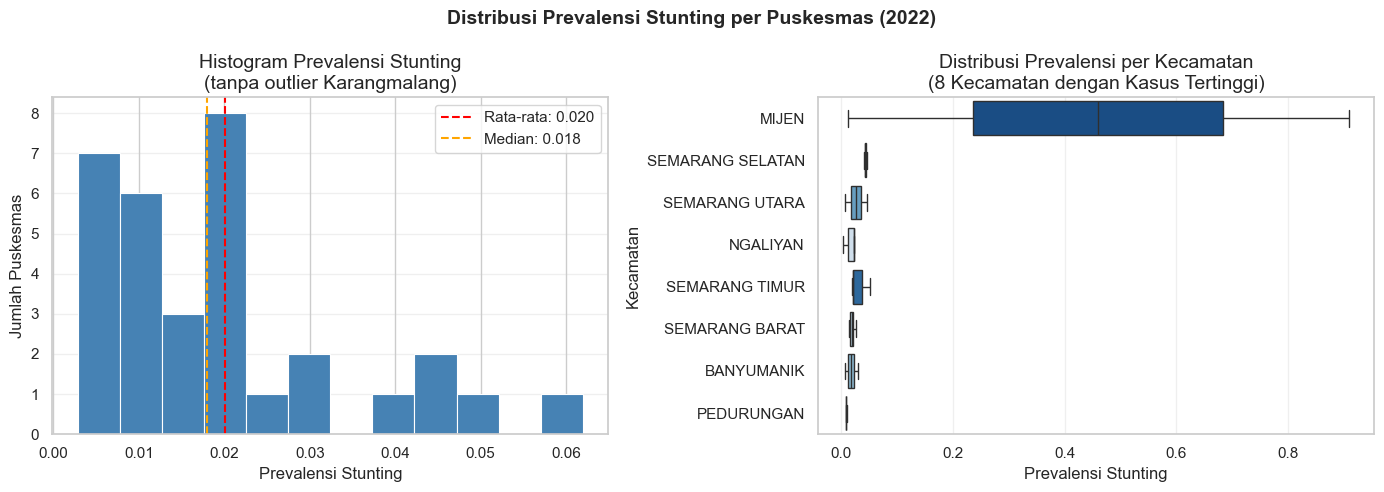

In [ ]:
# Visualisasi Prevalensi Stunting 
df_clean = df_yearly[df_yearly['prevalensi_stunting'] < 0.5].dropna(
    subset=['kasus_bblr', 'total_stunting', 'jml_posyandu', 'prevalensi_stunting', 'densitas_posyandu']
).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Prevalensi Stunting per Puskesmas (2022)', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df_clean['prevalensi_stunting'], bins=12, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].axvline(df_clean['prevalensi_stunting'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Rata-rata: {df_clean["prevalensi_stunting"].mean():.3f}')
axes[0].axvline(df_clean['prevalensi_stunting'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {df_clean["prevalensi_stunting"].median():.3f}')
axes[0].set_xlabel('Prevalensi Stunting')
axes[0].set_ylabel('Jumlah Puskesmas')
axes[0].set_title('Histogram Prevalensi Stunting\n(tanpa outlier Karangmalang)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot per kecamatan
kec_top8 = df_yearly.groupby('kecamatan')['total_stunting'].sum().nlargest(8).index
df_top = df_yearly[df_yearly['kecamatan'].isin(kec_top8)]
order = df_top.groupby('kecamatan')['prevalensi_stunting'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top, y='kecamatan', x='prevalensi_stunting', order=order,
            hue='kecamatan', palette='Blues_r', legend=False, ax=axes[1])
axes[1].set_xlabel('Prevalensi Stunting')
axes[1].set_ylabel('Kecamatan')
axes[1].set_title('Distribusi Prevalensi per Kecamatan\n(8 Kecamatan dengan Kasus Tertinggi)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/distribusi_prevalensi_stunting.png', dpi=150, bbox_inches='tight')
plt.show()

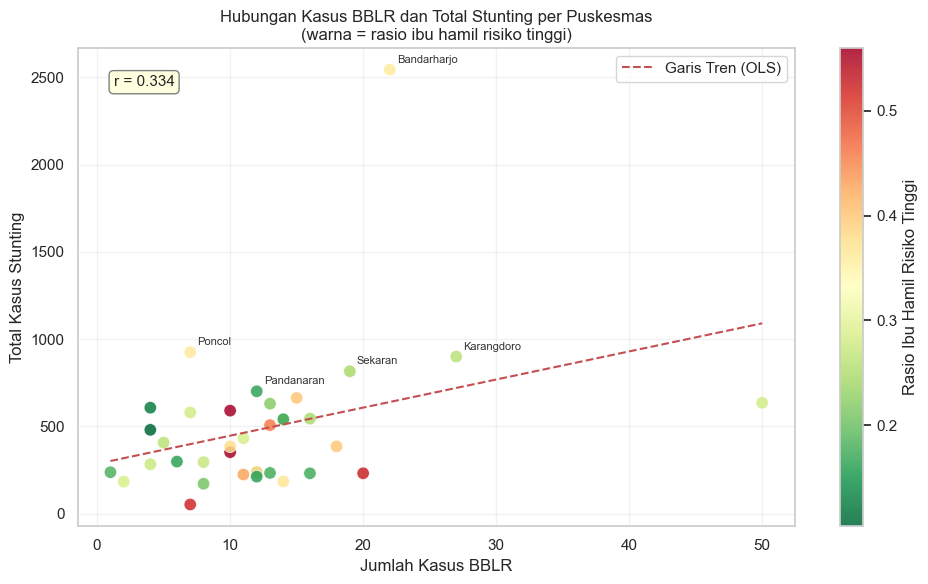

In [ ]:
# Hubungan BBLR vs Stunting 
df_bblr = df_yearly.dropna(subset=['kasus_bblr', 'total_stunting', 'rasio_risti']).copy()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_bblr['kasus_bblr'], df_bblr['total_stunting'],
                     c=df_bblr['rasio_risti'], cmap='RdYlGn_r',
                     s=80, alpha=0.85, edgecolors='white', linewidth=0.5)
z = np.polyfit(df_bblr['kasus_bblr'], df_bblr['total_stunting'], 1)
x_line = np.linspace(df_bblr['kasus_bblr'].min(), df_bblr['kasus_bblr'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=1.5, label='Garis Tren (OLS)')
for _, row in df_bblr.nlargest(5, 'total_stunting').iterrows():
    ax.annotate(row['puskesmas'].title(), (row['kasus_bblr'], row['total_stunting']),
                textcoords="offset points", xytext=(5, 5), fontsize=8, color='#333')
plt.colorbar(scatter, ax=ax, label='Rasio Ibu Hamil Risiko Tinggi')
ax.set_xlabel('Jumlah Kasus BBLR')
ax.set_ylabel('Total Kasus Stunting')
ax.set_title('Hubungan Kasus BBLR dan Total Stunting per Puskesmas\n(warna = rasio ibu hamil risiko tinggi)', fontsize=12)
ax.legend()
ax.grid(alpha=0.25)
corr_bblr = df_bblr['kasus_bblr'].corr(df_bblr['total_stunting'])
ax.text(0.05, 0.92, f'r = {corr_bblr:.3f}', transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
plt.tight_layout()
plt.savefig('../docs/bblr_vs_stunting.png', dpi=150, bbox_inches='tight')
plt.show()

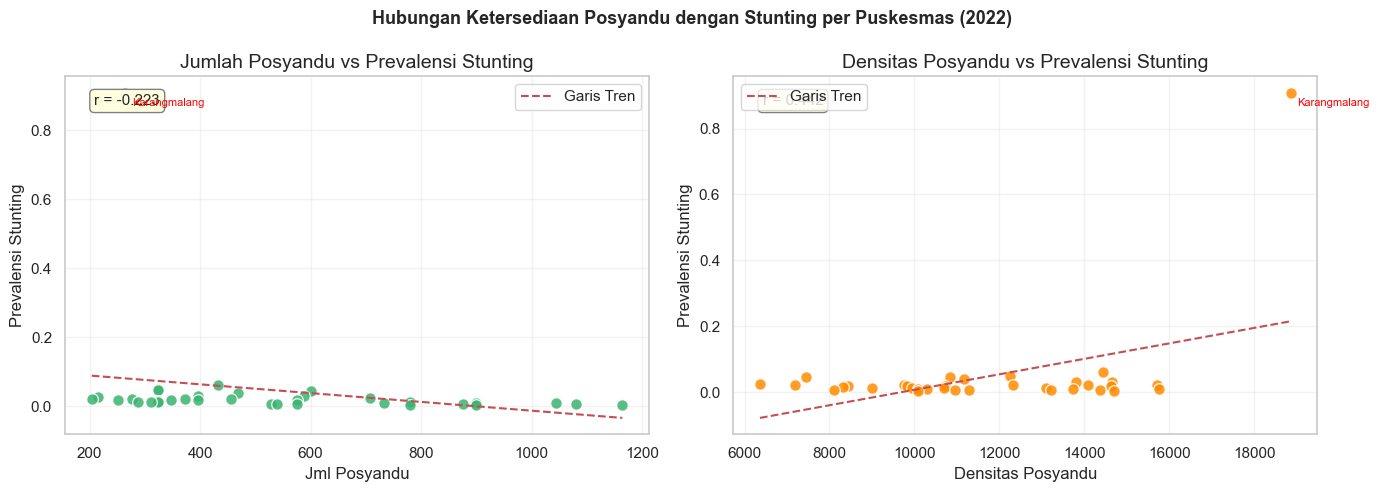

In [ ]:
# Posyandu vs Stunting 
df_pos = df_yearly.dropna(subset=['jml_posyandu', 'prevalensi_stunting', 'densitas_posyandu']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hubungan Ketersediaan Posyandu dengan Stunting per Puskesmas (2022)', fontsize=13, fontweight='bold')

for ax, xcol, color, title in [
    (axes[0], 'jml_posyandu',     'mediumseagreen', 'Jumlah Posyandu vs Prevalensi Stunting'),
    (axes[1], 'densitas_posyandu', 'darkorange',     'Densitas Posyandu vs Prevalensi Stunting'),
]:
    ax.scatter(df_pos[xcol], df_pos['prevalensi_stunting'],
               color=color, s=70, alpha=0.85, edgecolors='white')
    z = np.polyfit(df_pos[xcol], df_pos['prevalensi_stunting'], 1)
    x_r = np.linspace(df_pos[xcol].min(), df_pos[xcol].max(), 100)
    ax.plot(x_r, np.poly1d(z)(x_r), 'r--', linewidth=1.5, label='Garis Tren')
    r = df_pos[xcol].corr(df_pos['prevalensi_stunting'])
    ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
    km = df_pos[df_pos['puskesmas'] == 'KARANGMALANG']
    if not km.empty:
        ax.annotate('Karangmalang', (km[xcol].values[0], km['prevalensi_stunting'].values[0]),
                    textcoords='offset points', xytext=(5, -10), fontsize=8, color='red')
    ax.set_xlabel(xcol.replace('_', ' ').title())
    ax.set_ylabel('Prevalensi Stunting')
    ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('../docs/posyandu_vs_stunting.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Statistik Deskriptif

desc_vars = ['total_stunting', 'prevalensi_stunting', 'kasus_bblr', 
             'rasio_risti', 'jml_posyandu', 'capaian_imunisasi']

label_map = {
    'total_stunting':      'Total Kasus Stunting',
    'prevalensi_stunting': 'Prevalensi Stunting',
    'kasus_bblr':          'Kasus BBLR',
    'rasio_risti':         'Rasio Ibu Hamil Risti',
    'jml_posyandu':        'Jumlah Posyandu',
    'capaian_imunisasi':   'Capaian Imunisasi (%)',
}

desc = df_yearly[desc_vars].describe().T[['min', '50%', 'mean', 'max', 'std']]
desc.columns = ['Min', 'Median', 'Rata-rata', 'Maks', 'Std Dev']
desc.index = [label_map[i] for i in desc.index]

print("Statistik Deskriptif Variabel Utama (N=37 Puskesmas)")
print(desc.round(3).to_string())

Statistik Deskriptif Variabel Utama (N=37 Puskesmas)
                           Min   Median  Rata-rata      Maks  Std Dev
Total Kasus Stunting    52.000  407.000    494.622  2545.000  413.172
Prevalensi Stunting      0.003    0.020      0.046     0.909    0.153
Kasus BBLR               1.000   12.000     12.417    50.000    8.597
Rasio Ibu Hamil Risti    0.104    0.272      0.297     0.560    0.125
Jumlah Posyandu        204.000  432.000    526.054  1164.000  261.129
Capaian Imunisasi (%)   49.833   74.250     72.613    85.417    7.748


## Pemodelan Clustering (K-Means)
Tujuan: Memetakan Puskesmas ke dalam segmen kerentanan (Rendah, Sedang, Tinggi)


[EVALUASI CLUSTERING] Silhouette Score untuk K=3 adalah 0.5099

[PROFIL CLUSTER RATA-RATA]
                total_stunting  rasio_risti  kasus_bblr  capaian_imunisasi
cluster_risiko                                                            
0                   828.000000          NaN         NaN                NaN
1                   405.848485     0.296550   10.545455          72.512626
2                  1360.000000     0.301338   33.000000          73.722222


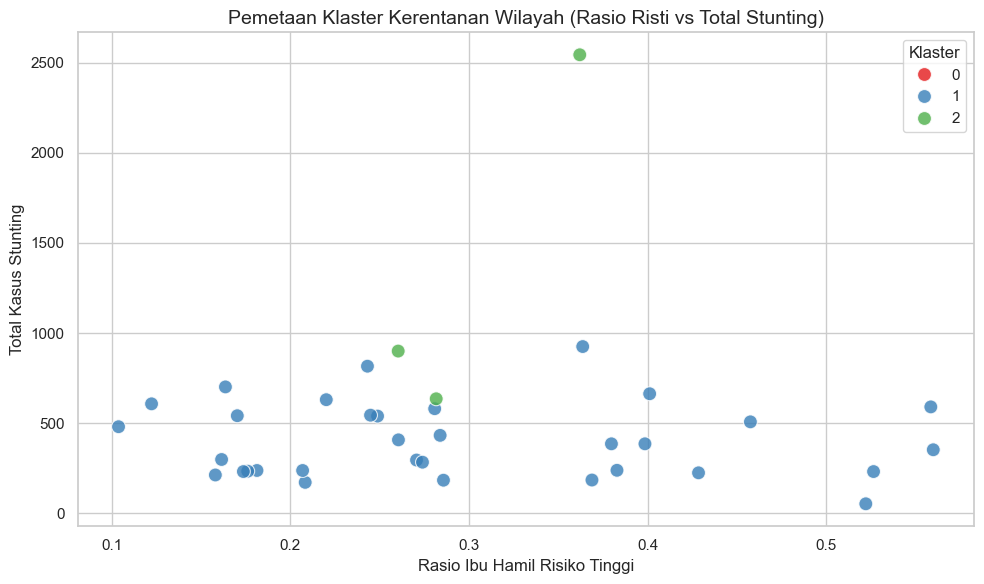

In [4]:
# Memilih fitur yang merepresentasikan kondisi kesehatan dan lingkungan
cluster_features = [
    'total_stunting', 'rasio_risti', 'kasus_bblr', 'capaian_imunisasi'
]
X_cluster = df_yearly[cluster_features].fillna(0) # Penanganan pengaman untuk NaNs

# Standarisasi fitur agar memiliki skala yang sama
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Menentukan nilai K optimal menggunakan Silhouette Score
silhouette_scores = []
K_range = range(2, 7)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

# Memilih K dengan skor silhouette tertinggi (biasanya k=3 untuk segmentasi risiko)
optimal_k = 3 
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_yearly['cluster_risiko'] = kmeans_final.fit_predict(X_scaled)

print(f"\n[EVALUASI CLUSTERING] Silhouette Score untuk K={optimal_k} adalah {silhouette_score(X_scaled, df_yearly['cluster_risiko']):.4f}")

# Analisis Karakteristik Setiap Cluster
cluster_profiling = df_yearly.groupby('cluster_risiko')[cluster_features].mean()
print("\n[PROFIL CLUSTER RATA-RATA]")
print(cluster_profiling)

# Visualisasi Hasil Clustering (2D Projection menggunakan 2 fitur utama)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_yearly, x='rasio_risti', y='total_stunting', hue='cluster_risiko', 
                palette='Set1', s=100, alpha=0.8)
plt.title('Pemetaan Klaster Kerentanan Wilayah (Rasio Risti vs Total Stunting)')
plt.xlabel('Rasio Ibu Hamil Risiko Tinggi')
plt.ylabel('Total Kasus Stunting')
plt.legend(title='Klaster')
plt.tight_layout()
plt.show()

## Feature Importance (Random Forest)
Tujuan : Menentukan faktor mana yang berkontribusi paling besar terhadap stunting

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22980\231643137.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances.head(10), x='Importance', y='Fitur', palette='mako')


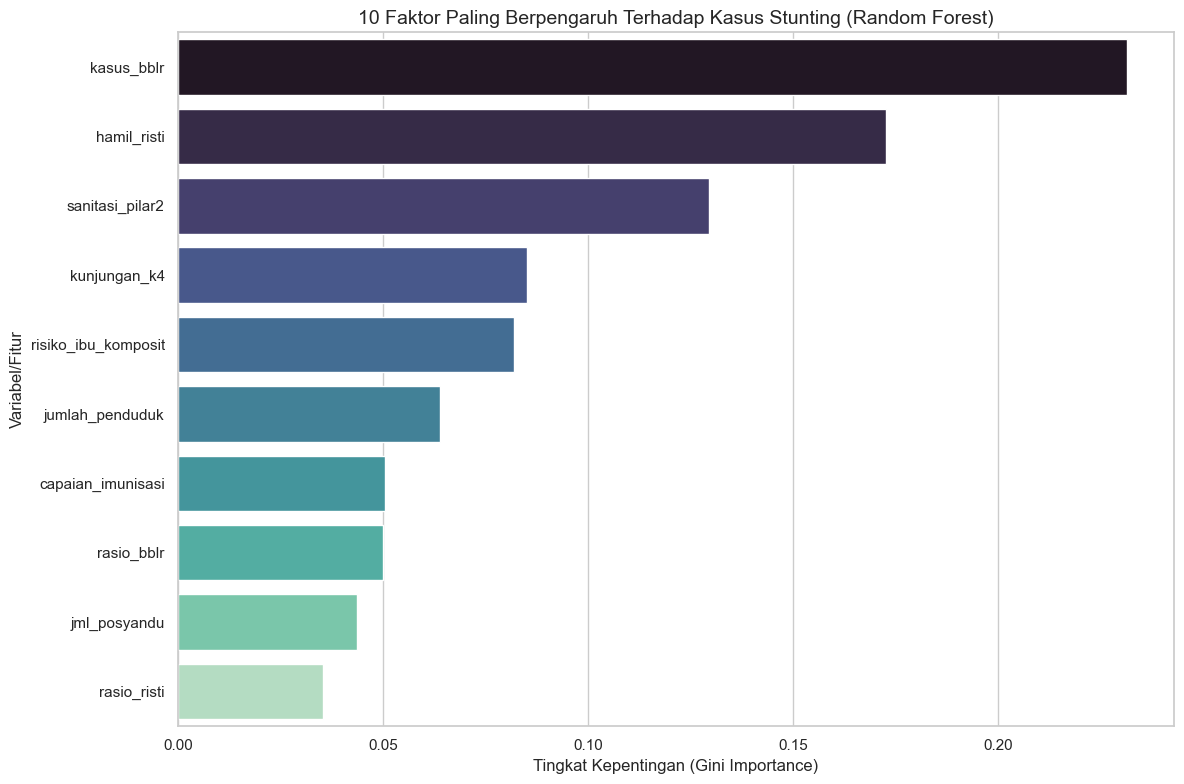


[EVALUASI MODEL REGRESI]
R-squared Score (Training): 0.7856

[INFO] Pipeline pemodelan selesai. Hasil klasterisasi disimpan di 'stunting_clustered_results.csv'


In [5]:
# Variabel prediktor potensial disesuaikan dengan kolom di stunting_agg_puskesmas_yearly
X_rf = df_yearly[[
    'jml_posyandu', 'luas_wilayah_km2', 'jumlah_penduduk', 
    'sanitasi_pilar1', 'sanitasi_pilar2', 'hamil_risti', 
    'rasio_risti', 'risiko_ibu_komposit', 'kunjungan_k4', 
    'kasus_bblr', 'rasio_bblr', 'capaian_imunisasi'
]].fillna(0)

y_rf = df_yearly['total_stunting'].fillna(0)

# Inisialisasi dan pelatihan model
# Menggunakan hiperparameter default yang optimal untuk dataset kecil/menengah
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10)
rf_model.fit(X_rf, y_rf)

# Ekstraksi dan pengurutan fitur berdasarkan tingkat kepentingan
feature_importances = pd.DataFrame({
    'Fitur': X_rf.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualisasi Feature Importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importances.head(10), x='Importance', y='Fitur', palette='mako')
plt.title('10 Faktor Paling Berpengaruh Terhadap Kasus Stunting (Random Forest)')
plt.xlabel('Tingkat Kepentingan (Gini Importance)')
plt.ylabel('Variabel/Fitur')
plt.tight_layout()
plt.savefig('../docs/feature_importance_rf.png', dpi=300)
plt.show()

print("\n[EVALUASI MODEL REGRESI]")
print(f"R-squared Score (Training): {rf_model.score(X_rf, y_rf):.4f}")

# Menyimpan dataset yang telah memiliki label klaster untuk diolah di Dashboard
df_yearly.to_csv('../data/integrated/stunting_clustered_results.csv', index=False)
print("\n[INFO] Pipeline pemodelan selesai. Hasil klasterisasi disimpan di 'stunting_clustered_results.csv'")